# 271. Which kmerseek region score to filter on: E-value, Poisson score, TF-IDF or mean IDF

kmerseek 0.4 reports four scores for every matched region. This notebook asks which one to set a
cut-off on, using the mini set, where Pfam says which hits are real.

| score (column) | what it is | better is |
|---|---|---|
| E-value (`region_evalue`) | expected number of chance regions this good per query, from the Karlin-Altschul score of the extended region | lower |
| Poisson score (`region_poisson_score`) | -log10 of the chance of seeing this many shared k-mers in a row if matches were random | higher |
| TF-IDF (`region_tfidf`) | sum over the region's k-mers of ln(number of targets / number of targets holding that k-mer) | higher |
| mean IDF (`region_mean_idf`) | TF-IDF divided by the number of shared k-mers: how rare the average k-mer is | higher |

**Data.** The 200 mini-set human queries against yeast (298 proteins) and E. coli (172 proteins),
kmerseek 0.4 with extension on, scaled 1, one k per alphabet (run `make run-mini-scaled-270
S270_RUN=extend` on branch `olgabot/scaled-sweep-270`). A second run (`S270_RUN=decoy`) searched
the same 200 queries after shuffling each one, keeping its amino-acid pairs. A shuffled query has
no real relatives, so every region it produces is a false hit.

**Labels for the real queries.**
- *same family* (true): at least half of the region lies in a Pfam domain on the human protein,
  and at least half of its target side lies in a domain of the same Pfam family on the target.
- *no shared family* (false): the human and target proteins share no Pfam family at all.
- *other*: the rest (left out).

**Hypotheses.**
1. Shuffled queries score like real queries hitting unrelated proteins. If so, the shuffled run is
   a fair source of false hits for setting cut-offs.
2. An E-value means what it says: with a cut-off of E, shuffled queries keep about E false regions
   per query. Fewer is safe (cautious); more means the E-value is too optimistic.
3. At the same false-hit rate, the best filter keeps the largest share of *same family* regions.

In [1]:
%matplotlib inline
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import region_filter_utils as rf

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(12)
pl.Config.set_tbl_width_chars(160)

FIG = "../figures/271_mini_pfam_"
TAB = "../tables/271_mini_pfam_"
COLOR_HP, COLOR_AA = "#d95f02", "#1b6ca8"
COLOR_TRUE = "#1a9850"

## 1. Regions per label

Every region from both runs, labelled. Hypothesis: the shuffled run gives about as many regions
as real queries give against proteins they share no family with, since both are chance hits.

In [2]:
regions = rf.load_all()
counts = (regions.group_by("alphabet", "label").len()
          .pivot(on="label", index="alphabet", values="len")
          .select("alphabet", "same family", "other", "no shared family", "shuffled")
          .sort(pl.col("alphabet").replace_strict({a: i for i, a in enumerate(rf.ALPHABET_K)})))
counts.write_csv(TAB + "regions_per_label.csv")
print("regions per label, yeast + E. coli")
print(counts)

regions per label, yeast + E. coli
shape: (8, 5)
┌──────────────────────────┬─────────────┬───────┬──────────────────┬──────────┐
│ alphabet                 ┆ same family ┆ other ┆ no shared family ┆ shuffled │
│ ---                      ┆ ---         ┆ ---   ┆ ---              ┆ ---      │
│ str                      ┆ u32         ┆ u32   ┆ u32              ┆ u32      │
╞══════════════════════════╪═════════════╪═══════╪══════════════════╪══════════╡
│ hp_lehninger_c_nonpolar2 ┆ 192         ┆ 4988  ┆ 161327           ┆ 162867   │
│ hp_thomas_dill2          ┆ 352         ┆ 7791  ┆ 242571           ┆ 245797   │
│ hp_thomas_dill_no_c2     ┆ 237         ┆ 10910 ┆ 388860           ┆ 389766   │
│ hp_kyte_doolittle2       ┆ 350         ┆ 16282 ┆ 485350           ┆ 529050   │
│ gbmr4                    ┆ 155         ┆ 2572  ┆ 57316            ┆ 49858    │
│ mmseqs12                 ┆ 581         ┆ 1661  ┆ 35640            ┆ 29550    │
│ sdm12                    ┆ 1910        ┆ 24146 ┆ 532530   

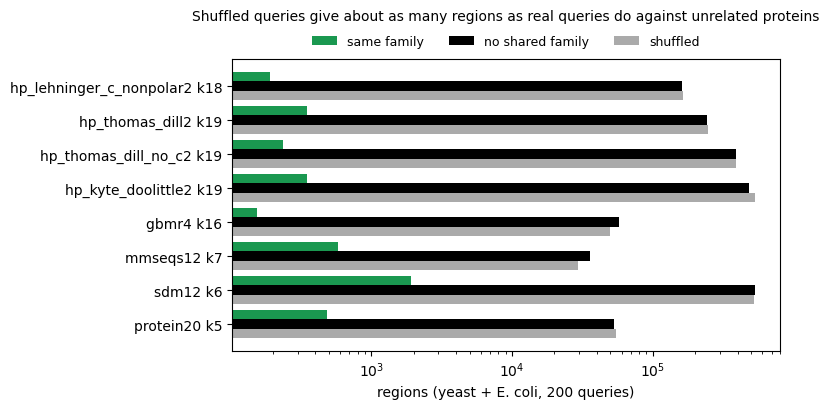

In [3]:
labels = [("same family", COLOR_TRUE), ("no shared family", "black"), ("shuffled", "#aaaaaa")]
fig, ax = plt.subplots(figsize=(8, 4.2))
y = np.arange(counts.height)
for i, (lab, c) in enumerate(labels):
    ax.barh(y + (i - 1) * 0.27, counts[lab], height=0.27, color=c, label=lab)
ax.set_yticks(y, [f"{a} k{rf.ALPHABET_K[a]}" for a in counts["alphabet"]])
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("regions (yeast + E. coli, 200 queries)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False, fontsize=9)
ax.set_title("Shuffled queries give about as many regions as real queries do against unrelated proteins",
             fontsize=10, pad=28)
fig.tight_layout()
fig.savefig(FIG + "regions_per_label.png", dpi=160, bbox_inches="tight")

## 2. Are shuffled queries a fair stand-in for real false hits?

Each score's distribution for the three labels, for one hydrophobic-polar alphabet
(hp_kyte_doolittle2 k19) and protein20 k5. Hypothesis 1 holds if the grey (shuffled) and dashed
(real query, unrelated target) histograms lie on top of each other. A useful score puts the green
(same family) histogram to the better side of both.

In [4]:
SHOWN = ["hp_kyte_doolittle2", "protein20"]
PANELS = [("region_evalue", "E-value", "lower = better"), ("region_poisson_score", "Poisson score", "higher = better"),
          ("region_tfidf", "TF-IDF", "higher = better"), ("region_mean_idf", "mean IDF", "higher = better")]
medians = (regions.filter(pl.col("alphabet").is_in(SHOWN) & (pl.col("label") != "other"))
           .group_by("alphabet", "label")
           .agg(n=pl.len(), **{name: pl.col(col).filter(pl.col(col).is_finite()).median().round(2) for col, name, _ in PANELS},
                no_evalue=pl.col("region_evalue").is_infinite().sum())
           .sort("alphabet", "label"))
medians.write_csv(TAB + "score_medians_by_label.csv")
print("median of each score by label (no_evalue = regions whose E-value is infinite, left out of the median)")
print(medians)

median of each score by label (no_evalue = regions whose E-value is infinite, left out of the median)
shape: (6, 8)
┌────────────────────┬──────────────────┬────────┬─────────┬───────────────┬────────┬──────────┬───────────┐
│ alphabet           ┆ label            ┆ n      ┆ E-value ┆ Poisson score ┆ TF-IDF ┆ mean IDF ┆ no_evalue │
│ ---                ┆ ---              ┆ ---    ┆ ---     ┆ ---           ┆ ---    ┆ ---      ┆ ---       │
│ str                ┆ str              ┆ u32    ┆ f64     ┆ f64           ┆ f64    ┆ f64      ┆ u32       │
╞════════════════════╪══════════════════╪════════╪═════════╪═══════════════╪════════╪══════════╪═══════════╡
│ hp_kyte_doolittle2 ┆ no shared family ┆ 485350 ┆ 1689.07 ┆ 0.99          ┆ 74.97  ┆ 36.01    ┆ 70232     │
│ hp_kyte_doolittle2 ┆ same family      ┆ 350    ┆ 1644.04 ┆ 2.46          ┆ 50.58  ┆ 18.65    ┆ 2         │
│ hp_kyte_doolittle2 ┆ shuffled         ┆ 529050 ┆ 1796.27 ┆ 1.04          ┆ 69.34  ┆ 33.72    ┆ 60638     │
│ protein20 

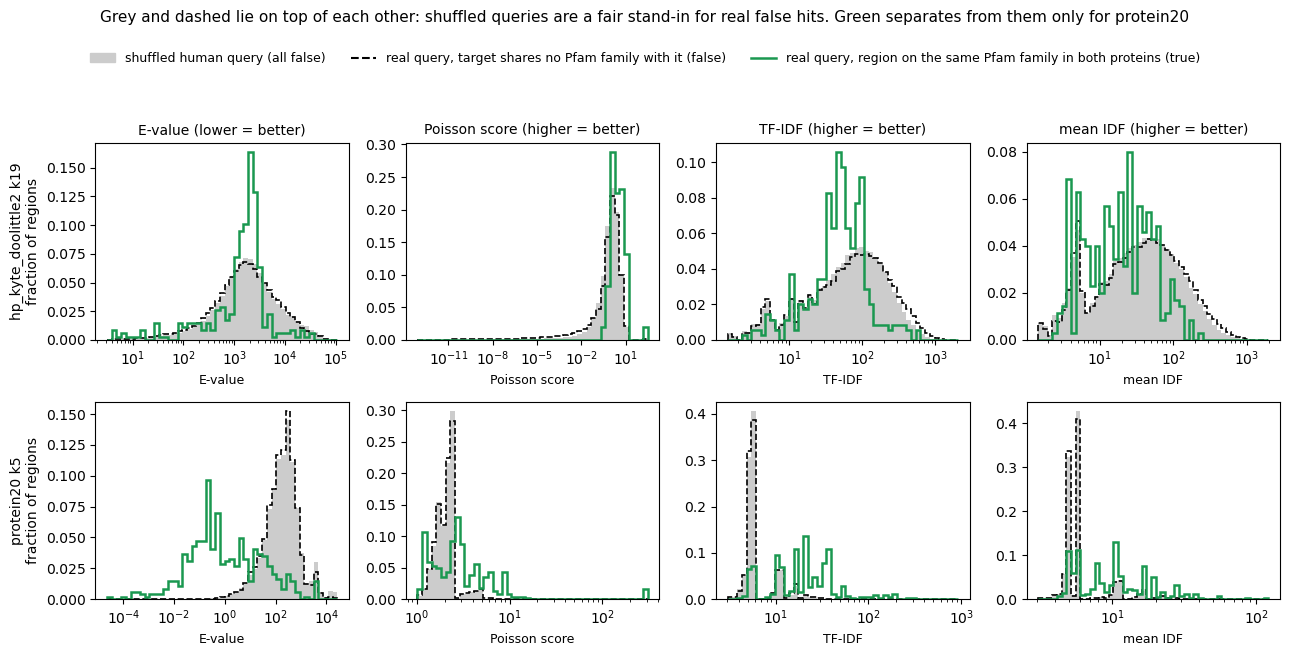

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6.2))
for i, a in enumerate(SHOWN):
    sub = regions.filter(pl.col("alphabet") == a)
    for j, (col, name, better) in enumerate(PANELS):
        ax = axes[i, j]
        finite = sub.filter(pl.col(col).is_finite() & (pl.col(col) > 0))
        v_all = finite[col].to_numpy()
        bins = np.logspace(np.log10(np.percentile(v_all, 0.1)), np.log10(v_all.max()), 50)
        for lab, kw in [("shuffled", dict(histtype="stepfilled", color="#cccccc")),
                        ("no shared family", dict(histtype="step", color="black", ls="--", lw=1.2)),
                        ("same family", dict(histtype="step", color=COLOR_TRUE, lw=1.8))]:
            v = finite.filter(pl.col("label") == lab)[col].to_numpy()
            ax.hist(v, bins=bins, weights=np.full(len(v), 1 / max(len(v), 1)), **kw)
        ax.set_xscale("log")
        if i == 0:
            ax.set_title(f"{name} ({better})", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"{a} k{rf.ALPHABET_K[a]}\nfraction of regions")
        ax.set_xlabel(name, fontsize=9)
handles = [plt.Rectangle((0, 0), 1, 1, color="#cccccc", label="shuffled human query (all false)"),
           Line2D([], [], color="black", ls="--", label="real query, target shares no Pfam family with it (false)"),
           Line2D([], [], color=COLOR_TRUE, lw=1.8, label="real query, region on the same Pfam family in both proteins (true)")]
fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.0))
fig.suptitle("Grey and dashed lie on top of each other: shuffled queries are a fair stand-in for real false hits. "
             "Green separates from them only for protein20", fontsize=11, y=1.05)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(FIG + "score_distributions_by_label.png", dpi=160, bbox_inches="tight")

## 3. Do the E-values mean what they say?

Every region from a shuffled query is false, so the number of shuffled regions passing a cut-off
of E, divided by the 400 query searches (200 queries x 2 species), should be about E. The grey
band marks that line. A curve below it is cautious (fewer false hits than promised); above it is
too optimistic.

Left: kmerseek's E-value. Right: the Poisson score turned into an E-value the way kmerseek's own
documentation suggests: the Poisson tail probability x the number of positions the region could
have started at x the number of targets. gbmr4 is left out: none of its regions has an E-value
(every value is infinite, because no Karlin-Altschul lambda exists for its letter frequencies).

In [6]:
CUTOFFS = np.logspace(-4, 2, 61)
TABLE_CUTOFFS = [0.001, 0.01, 0.1, 1, 10]
shuffled = regions.filter(pl.col("label") == "shuffled")
rows = []
for col in ["region_evalue", "poisson_evalue"]:
    for a in rf.HP_ALPHABETS + rf.AMINO_ACID_LIKE:
        v = shuffled.filter(pl.col("alphabet") == a)[col].to_numpy()
        per_q = rf.false_hits_per_query(v, np.array(TABLE_CUTOFFS))
        rows.append({"score": col, "alphabet": a, **{f"E<={t:g}": round(float(x), 4) for t, x in zip(TABLE_CUTOFFS, per_q)}})
calibration = pl.DataFrame(rows)
calibration.write_csv(TAB + "shuffled_false_hits_per_query.csv")
print("shuffled-query regions kept per query search at each E-value cut-off (correct = equal to the cut-off)")
print(calibration)

shuffled-query regions kept per query search at each E-value cut-off (correct = equal to the cut-off)
shape: (14, 7)
┌────────────────┬──────────────────────────┬──────────┬─────────┬─────────┬─────────┬─────────┐
│ score          ┆ alphabet                 ┆ E<=0.001 ┆ E<=0.01 ┆ E<=0.1  ┆ E<=1    ┆ E<=10   │
│ ---            ┆ ---                      ┆ ---      ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ str            ┆ str                      ┆ f64      ┆ f64     ┆ f64     ┆ f64     ┆ f64     │
╞════════════════╪══════════════════════════╪══════════╪═════════╪═════════╪═════════╪═════════╡
│ region_evalue  ┆ hp_lehninger_c_nonpolar2 ┆ 0.0      ┆ 0.0     ┆ 0.045   ┆ 0.585   ┆ 7.585   │
│ region_evalue  ┆ hp_thomas_dill2          ┆ 0.0025   ┆ 0.005   ┆ 0.02    ┆ 0.34    ┆ 4.52    │
│ region_evalue  ┆ hp_thomas_dill_no_c2     ┆ 0.0      ┆ 0.0025  ┆ 0.005   ┆ 0.205   ┆ 4.0025  │
│ region_evalue  ┆ hp_kyte_doolittle2       ┆ 0.0      ┆ 0.0     ┆ 0.01    ┆ 0.2075  ┆ 3.29    │
│ region_e

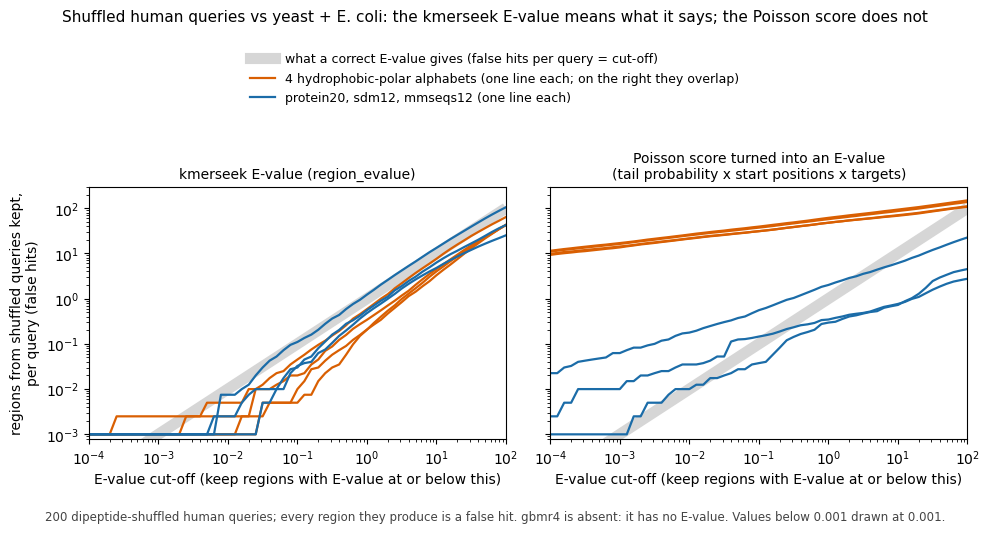

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharey=True)
for ax, col, title in [(axes[0], "region_evalue", "kmerseek E-value (region_evalue)"),
                       (axes[1], "poisson_evalue", "Poisson score turned into an E-value\n"
                        "(tail probability x start positions x targets)")]:
    ax.plot(CUTOFFS, CUTOFFS, color="#bbbbbb", lw=8, alpha=0.6, solid_capstyle="butt", zorder=1)
    for alphas, c in [(rf.HP_ALPHABETS, COLOR_HP), (rf.AMINO_ACID_LIKE, COLOR_AA)]:
        for a in alphas:
            v = shuffled.filter(pl.col("alphabet") == a)[col].to_numpy()
            ax.plot(CUTOFFS, np.maximum(rf.false_hits_per_query(v, CUTOFFS), 1e-3), color=c, lw=1.6, zorder=2)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylim(8e-4, 300); ax.set_xlim(1e-4, 1e2)
    ax.set_xlabel("E-value cut-off (keep regions with E-value at or below this)")
    ax.set_title(title, fontsize=10)
axes[0].set_ylabel("regions from shuffled queries kept,\nper query (false hits)")
fig.legend(handles=[Line2D([], [], color="#bbbbbb", lw=8, alpha=0.6, label="what a correct E-value gives (false hits per query = cut-off)"),
                    Line2D([], [], color=COLOR_HP, lw=1.6, label="4 hydrophobic-polar alphabets (one line each; on the right they overlap)"),
                    Line2D([], [], color=COLOR_AA, lw=1.6, label="protein20, sdm12, mmseqs12 (one line each)")],
           loc="upper center", frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.0))
fig.suptitle("Shuffled human queries vs yeast + E. coli: the kmerseek E-value means what it says; the Poisson score does not",
             fontsize=11, y=1.07)
fig.text(0.5, -0.04, "200 dipeptide-shuffled human queries; every region they produce is a false hit. "
         "gbmr4 is absent: it has no E-value. Values below 0.001 drawn at 0.001.",
         ha="center", fontsize=8.5, color="#444444")
fig.tight_layout(rect=(0, 0, 1, 0.86))
fig.savefig(FIG + "evalue_calibration_shuffled_queries.png", dpi=160, bbox_inches="tight")

## 4. Which filter keeps the most true regions at the same false-hit rate?

Each score gets its own cut-off, set so that shuffled queries let through 1 false region per 10
query searches (40 of 400). This puts every score on the same footing, whatever its units. Higher
is better: the share of *same family* regions that pass. Region length alone is the reference: a
score that does no better than length adds nothing over "keep the long regions".

In [8]:
FALSE_PER_QUERY = 0.1
rows = []
for a in rf.ALPHABET_K:
    sub = regions.filter(pl.col("alphabet") == a)
    true = sub.filter(pl.col("label") == "same family")
    shuf = sub.filter(pl.col("label") == "shuffled")
    for name in rf.SCORES:
        cutoff, kept = rf.kept_at_false_rate(true[name].to_numpy(), shuf[name].to_numpy(), FALSE_PER_QUERY)
        rows.append(dict(alphabet=a, k=rf.ALPHABET_K[a], score=name, n_same_family=true.height,
                         cutoff=round(cutoff, 2), percent_kept=round(100 * kept, 1)))
kept = pl.DataFrame(rows)
kept.write_csv(TAB + "same_family_kept_at_0.1_false_per_query.csv")
print(f"% of same-family regions kept when shuffled queries pass {FALSE_PER_QUERY} false regions per query")
print(kept.pivot(on="score", index=["alphabet", "k", "n_same_family"], values="percent_kept"))
print("cut-off for each score (higher-is-better scale; E-value shown as -log10 E; -1e6 = no E-value at all)")
print(kept.pivot(on="score", index="alphabet", values="cutoff"))

% of same-family regions kept when shuffled queries pass 0.1 false regions per query
shape: (8, 8)
┌──────────────────────────┬─────┬───────────────┬─────────┬───────────────┬────────┬──────────┬───────────────┐
│ alphabet                 ┆ k   ┆ n_same_family ┆ E-value ┆ Poisson score ┆ TF-IDF ┆ mean IDF ┆ region length │
│ ---                      ┆ --- ┆ ---           ┆ ---     ┆ ---           ┆ ---    ┆ ---      ┆ ---           │
│ str                      ┆ i64 ┆ i64           ┆ f64     ┆ f64           ┆ f64    ┆ f64      ┆ f64           │
╞══════════════════════════╪═════╪═══════════════╪═════════╪═══════════════╪════════╪══════════╪═══════════════╡
│ hp_lehninger_c_nonpolar2 ┆ 18  ┆ 192           ┆ 6.8     ┆ 0.0           ┆ 1.0    ┆ 0.0      ┆ 2.1           │
│ hp_thomas_dill2          ┆ 19  ┆ 352           ┆ 4.3     ┆ 0.0           ┆ 0.0    ┆ 0.0      ┆ 0.0           │
│ hp_thomas_dill_no_c2     ┆ 19  ┆ 237           ┆ 5.5     ┆ 0.0           ┆ 0.0    ┆ 0.0      ┆ 0.0          

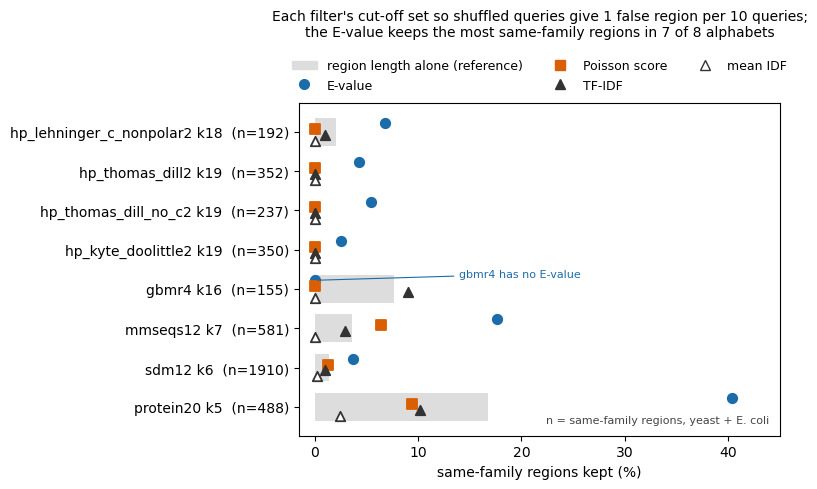

In [9]:
order = list(rf.ALPHABET_K)
MARKS = [("E-value", "o", COLOR_AA, True), ("Poisson score", "s", COLOR_HP, True),
         ("TF-IDF", "^", "#333333", True), ("mean IDF", "^", "#333333", False)]
fig, ax = plt.subplots(figsize=(8, 5))
yy = np.arange(len(order))
pct = {(r["alphabet"], r["score"]): r["percent_kept"] for r in kept.iter_rows(named=True)}
n_true = {r["alphabet"]: r["n_same_family"] for r in kept.iter_rows(named=True)}
ax.barh(yy, [pct[(a, "region length")] for a in order], height=0.7, color="#dddddd", zorder=1)
for i, (s, m, c, filled) in enumerate(MARKS):
    ax.scatter([pct[(a, s)] for a in order], yy + (i - 1.5) * 0.15, marker=m, s=46,
               facecolors=c if filled else "white", edgecolors=c, lw=1.3, zorder=3)
ax.set_yticks(yy, [f"{a} k{rf.ALPHABET_K[a]}  (n={n_true[a]})" for a in order])
ax.invert_yaxis()
ax.set_xlabel("same-family regions kept (%)")
ax.set_xlim(-1.5, 45)
ax.annotate("gbmr4 has no E-value", xy=(0, order.index("gbmr4") - 0.22), xytext=(14, order.index("gbmr4") - 0.3),
            fontsize=8, color=COLOR_AA, arrowprops=dict(arrowstyle="-", color=COLOR_AA, lw=0.8))
handles = [plt.Rectangle((0, 0), 1, 1, color="#dddddd", label="region length alone (reference)")] + [
    Line2D([], [], marker=m, ls="", color=c, markerfacecolor=c if f else "white", markersize=7, label=s)
    for s, m, c, f in MARKS]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False, fontsize=9)
ax.set_title("Each filter's cut-off set so shuffled queries give 1 false region per 10 queries;\n"
             "the E-value keeps the most same-family regions in 7 of 8 alphabets", fontsize=10, pad=48)
ax.text(44, len(order) - 0.6, "n = same-family regions, yeast + E. coli", ha="right", fontsize=8, color="#444444")
fig.tight_layout()
fig.savefig(FIG + "same_family_kept_at_fixed_false_rate.png", dpi=160, bbox_inches="tight")

# Summary and Conclusions

## Background

kmerseek 0.4 reports four scores per matched region: E-value, Poisson score, TF-IDF and mean IDF.
This notebook asks which one to filter on, using 200 mini-set human queries against yeast and
E. coli, Pfam families as the truth, and shuffled copies of the queries as a source of known false hits.

## Summary and Conclusions

* Shuffled human queries give within 18% as many regions as real queries give against proteins sharing no Pfam family, with the same score distributions, so they are a fair source of false hits.
* kmerseek's E-value is cautious: at E <= 1, shuffled queries keep 0.20-0.59 false regions per query search in 6 of 7 alphabets, and sdm12 keeps 1.23.
* The Poisson score, turned into an E-value as kmerseek's documentation suggests, lets 14-17 false regions per query search through at E <= 0.001 for all four hydrophobic-polar alphabets.
* At 1 false region per 10 query searches, the E-value keeps 40% of same-family regions for protein20 k5 and 18% for mmseqs12 k7, more than any other score.
* No score works for hydrophobic-polar alphabets: at that false-hit rate the E-value keeps 3-7% of same-family regions, and Poisson score, TF-IDF and mean IDF keep 0-1%.
* hp_kyte_doolittle2 k19 same-family regions have the same median E-value as shuffled-query regions (1644 vs 1796) and a lower median mean IDF (19 vs 34).
* TF-IDF and mean IDF keep no more same-family regions than region length alone: mean IDF is at or below length in all 8 alphabets.
* gbmr4 k16 cannot be filtered on E-value: every one of its regions has an infinite E-value.

## Analysis Details

Recommendation: filter on `region_evalue`. A cut-off of E <= 10 lets 3.3-13.2 false regions per
query search through; E <= 0.1 lets 0.005-0.11 through. Do not use `region_poisson_score` as a
cut-off. `query_tfidf` is one value per query, the same on every target, so it cannot filter regions.

Section 1 labels every region. Section 2 compares score distributions by label (higher or lower is
better as marked on each panel). Section 3 counts, for each E-value cut-off, how many shuffled-query
regions pass, per query search: a correct E-value gives a count equal to the cut-off. Section 4 sets
each score's cut-off so shuffled queries pass 40 of 400 query searches and reports the share of
same-family regions that pass; higher is better.

The Poisson score has a ceiling of 307.65, and shuffled-query regions reach it (0.07-0.22% of them
in the hydrophobic-polar alphabets). That is why its cut-off in section 4 sits at the ceiling and
keeps nothing.

## Supplementary Information

- Data: `~/data/qfo-pfam-region-benchmark-mini-scaled-270/{extend,decoy}/kmerseek`, copied from
  Sherlock `/scratch/users/olgabot/2024-kmerseek-scaled-270/nextflow-runs/qfo-pfam-region-benchmark/data/mini-scaled-270/` on 2026-10-01.
  Only the scaled-1 files are used. Pfam domains from `annotations/{human,yeast,ecoli}_pfam_domains.parquet`.
- kmerseek 0.4.0 (extension on), one k per alphabet as in `region_filter_utils.ALPHABET_K`.
- E. coli contributes few same-family regions (1-45 per alphabet); yeast drives most numbers.
- hp_pbotc_1st_ed is not in this run.
- Tables: `tables/271_mini_pfam_*.csv`. Figures: `figures/271_mini_pfam_*.png`.

## References

- kmerseek 0.4.0 doc comments on `MatchedRegion::poisson_score`, `tfidf`, `mean_idf`, `ka_bits` and
  `evalue` (`src/rust/search.rs`), which define each score and the Poisson-to-E-value conversion.
- Karlin, S., and S. F. Altschul. "Methods for Assessing the Statistical Significance of Molecular
  Sequence Features by Using General Scoring Schemes." *Proceedings of the National Academy of
  Sciences* 87, no. 6 (1990): 2264-68. (DOI still needs checking.)

In [10]:
print('# Summary and Conclusions\n\n## Background\n\nkmerseek 0.4 reports four scores per matched region: E-value, Poisson score, TF-IDF and mean IDF.\nThis notebook asks which one to filter on, using 200 mini-set human queries against yeast and\nE. coli, Pfam families as the truth, and shuffled copies of the queries as a source of known false hits.\n\n## Summary and Conclusions\n\n* Shuffled human queries give within 18% as many regions as real queries give against proteins sharing no Pfam family, with the same score distributions, so they are a fair source of false hits.\n* kmerseek\'s E-value is cautious: at E <= 1, shuffled queries keep 0.20-0.59 false regions per query search in 6 of 7 alphabets, and sdm12 keeps 1.23.\n* The Poisson score, turned into an E-value as kmerseek\'s documentation suggests, lets 14-17 false regions per query search through at E <= 0.001 for all four hydrophobic-polar alphabets.\n* At 1 false region per 10 query searches, the E-value keeps 40% of same-family regions for protein20 k5 and 18% for mmseqs12 k7, more than any other score.\n* No score works for hydrophobic-polar alphabets: at that false-hit rate the E-value keeps 3-7% of same-family regions, and Poisson score, TF-IDF and mean IDF keep 0-1%.\n* hp_kyte_doolittle2 k19 same-family regions have the same median E-value as shuffled-query regions (1644 vs 1796) and a lower median mean IDF (19 vs 34).\n* TF-IDF and mean IDF keep no more same-family regions than region length alone: mean IDF is at or below length in all 8 alphabets.\n* gbmr4 k16 cannot be filtered on E-value: every one of its regions has an infinite E-value.\n\n## Analysis Details\n\nRecommendation: filter on `region_evalue`. A cut-off of E <= 10 lets 3.3-13.2 false regions per\nquery search through; E <= 0.1 lets 0.005-0.11 through. Do not use `region_poisson_score` as a\ncut-off. `query_tfidf` is one value per query, the same on every target, so it cannot filter regions.\n\nSection 1 labels every region. Section 2 compares score distributions by label (higher or lower is\nbetter as marked on each panel). Section 3 counts, for each E-value cut-off, how many shuffled-query\nregions pass, per query search: a correct E-value gives a count equal to the cut-off. Section 4 sets\neach score\'s cut-off so shuffled queries pass 40 of 400 query searches and reports the share of\nsame-family regions that pass; higher is better.\n\nThe Poisson score has a ceiling of 307.65, and shuffled-query regions reach it (0.07-0.22% of them\nin the hydrophobic-polar alphabets). That is why its cut-off in section 4 sits at the ceiling and\nkeeps nothing.\n\n## Supplementary Information\n\n- Data: `~/data/qfo-pfam-region-benchmark-mini-scaled-270/{extend,decoy}/kmerseek`, copied from\n  Sherlock `/scratch/users/olgabot/2024-kmerseek-scaled-270/nextflow-runs/qfo-pfam-region-benchmark/data/mini-scaled-270/` on 2026-10-01.\n  Only the scaled-1 files are used. Pfam domains from `annotations/{human,yeast,ecoli}_pfam_domains.parquet`.\n- kmerseek 0.4.0 (extension on), one k per alphabet as in `region_filter_utils.ALPHABET_K`.\n- E. coli contributes few same-family regions (1-45 per alphabet); yeast drives most numbers.\n- hp_pbotc_1st_ed is not in this run.\n- Tables: `tables/271_mini_pfam_*.csv`. Figures: `figures/271_mini_pfam_*.png`.\n\n## References\n\n- kmerseek 0.4.0 doc comments on `MatchedRegion::poisson_score`, `tfidf`, `mean_idf`, `ka_bits` and\n  `evalue` (`src/rust/search.rs`), which define each score and the Poisson-to-E-value conversion.\n- Karlin, S., and S. F. Altschul. "Methods for Assessing the Statistical Significance of Molecular\n  Sequence Features by Using General Scoring Schemes." *Proceedings of the National Academy of\n  Sciences* 87, no. 6 (1990): 2264-68. (DOI still needs checking.)')

# Summary and Conclusions

## Background

kmerseek 0.4 reports four scores per matched region: E-value, Poisson score, TF-IDF and mean IDF.
This notebook asks which one to filter on, using 200 mini-set human queries against yeast and
E. coli, Pfam families as the truth, and shuffled copies of the queries as a source of known false hits.

## Summary and Conclusions

* Shuffled human queries give within 18% as many regions as real queries give against proteins sharing no Pfam family, with the same score distributions, so they are a fair source of false hits.
* kmerseek's E-value is cautious: at E <= 1, shuffled queries keep 0.20-0.59 false regions per query search in 6 of 7 alphabets, and sdm12 keeps 1.23.
* The Poisson score, turned into an E-value as kmerseek's documentation suggests, lets 14-17 false regions per query search through at E <= 0.001 for all four hydrophobic-polar alphabets.
* At 1 false region per 10 query searches, the E-value keeps 40% of same-family regions for protei